In [9]:
##### Creates maps of agricultural capital and labor intensities 
# Side-by-side of pixel intensities and country intensities 

import os
import pandas as pd
import geopandas as gpd
import rioxarray as rio
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from glob import glob
import rasterio
from rasterio.warp import reproject, Resampling
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from pyproj import Transformer
import matplotlib.patches as mpatches
from matplotlib.colors import to_hex, Normalize
from matplotlib import cm
import matplotlib
from matplotlib.patches import Rectangle
from rasterstats import zonal_stats

In [6]:
##### Load data

# Get the current working directory
cd = os.path.dirname(os.getcwd())

# pixel data
capital_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/capital_intensity_USD_per_tonne.tif")
labor_intensity = rio.open_rasterio(f"{cd}/Results/Raster_model/labor_intensity_jobs_per_tonne.tif")

# sub-national data 
sub_national_capital = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_capital_intensity.csv")
sub_national_labor = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_labor_intensity.csv")
sub_national_capital_geo = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_capital.shp")
sub_national_labor_geo = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_labor.shp")

# national data
country_intensities = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
country_boundaries = gpd.read_file(f"{cd}/Data/Clean/Geographies/country_geo.shp")
country_codes = pd.read_csv(f"{cd}/Data/Correspondence_tables/country_names.csv", encoding="cp1252")

has_data = pd.read_csv(f'{cd}/Data/Correspondence_tables/has_data.csv')

# Set file path to figure repo
fd = "/Users/carinamanitius/Library/CloudStorage/OneDrive-UniversityofVermont/Documents/OneDrive/Dissertation/Chapter 1/Figures/RESULTS/map_intensity_side_by_side"

In [7]:
### Data prep

target_crs = "+proj=eck4 +lon_0=0 +x_0=0 +y_0=0 +datum=WGS84 +units=m +no_defs"

capital_intensity = capital_intensity.rio.reproject(target_crs)

labor_intensity = labor_intensity.rio.reproject_match(capital_intensity)

country_boundaries = country_boundaries.to_crs(capital_intensity.rio.crs)
sub_national_capital_geo = sub_national_capital_geo.to_crs(capital_intensity.rio.crs)
sub_national_labor_geo = sub_national_labor_geo.to_crs(capital_intensity.rio.crs)

# add geo to country / sub-national intensities 
country_boundaries = country_boundaries.merge(country_intensities, on='ISO3', how='left')

sub_national_capital = sub_national_capital_geo.merge(sub_national_capital, on='PROJ_ID', how='left')
sub_national_labor = sub_national_labor_geo.merge(sub_national_labor, on='PROJ_ID', how='left')

In [8]:
##### Identify no data countries 

country_boundaries = country_boundaries.merge(has_data, on='SHP_code', how='left')
country_boundaries['has_capital_data'] = country_boundaries['has_capital_data'].fillna(0)
country_boundaries['has_labor_data'] = country_boundaries['has_labor_data'].fillna(0)

#### Map intensity rasters

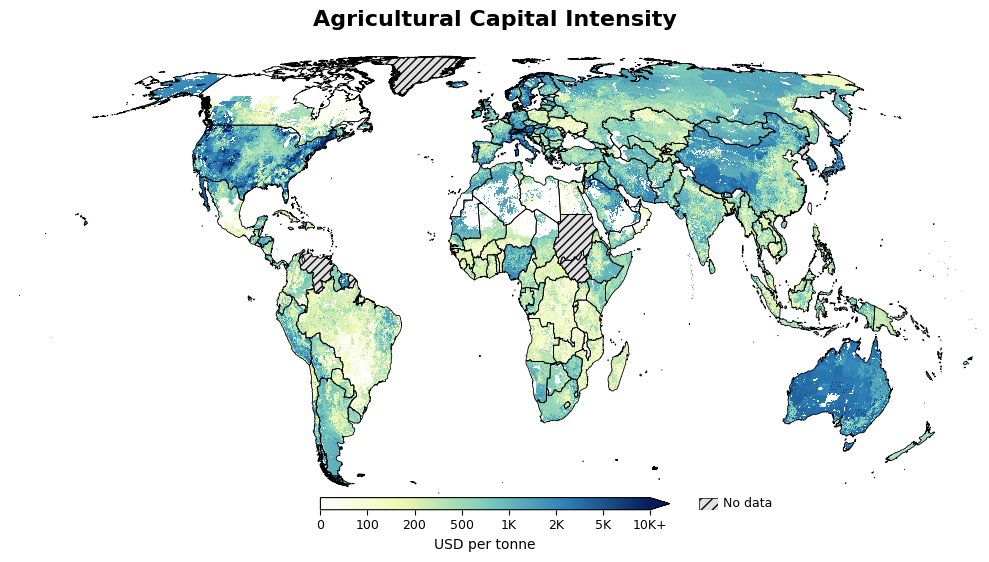

In [26]:
##### Produce global map of capital intensity

# Prepare raster
value_plot = capital_intensity.squeeze()
name = 'capital_intensity'

# set custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_ylgnbu",
    ["#ffffff", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
)
custom_cmap.set_over("#081d58")  # color for the + triangle

# Set special equal-distant, manual scalling
bounds = [0, 100, 200, 500, 1000, 2000, 5000, 10000]      
labels = ['0', '100', '200', '500', '1K', '2K', '5K', '10K+']            

positions = np.linspace(0, 1, len(bounds))  # each bound gets an equal-width slice

def forward(x):
    return np.interp(x, bounds, positions)

def inverse(x):
    return np.interp(x, positions, bounds)

norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Countries with no data (light grey fill with hatching)
no_data_color = "#e0e0e0"
country_boundaries[country_boundaries["has_capital_data"] == 0].plot(
    ax=ax,
    facecolor=no_data_color,
    edgecolor="none",
    hatch="////",
    zorder=0
)

# Country borders
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap=custom_cmap,
    norm=norm,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

ax.set_axis_off()
ax.set_title("Agricultural Capital Intensity", fontsize=16, weight='bold', pad=20)

# Generate legend 
cax = ax.inset_axes([0.32, 0.06, 0.36, 0.025], transform=ax.transAxes)

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    extend='max',       
    extendfrac=0.06,    
)
cbar.set_label("USD per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

# Add no data to legend
legend_ax = ax.inset_axes([0.71, 0.06, 0.02, 0.025], transform=ax.transAxes)
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1,
    facecolor=no_data_color,
    edgecolor="black",
    linewidth=0.5,
    hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.axis("off")

ax.text(
    0.735, 0.072, "No data",
    transform=ax.transAxes,
    fontsize=9, va="center", ha="left"
)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

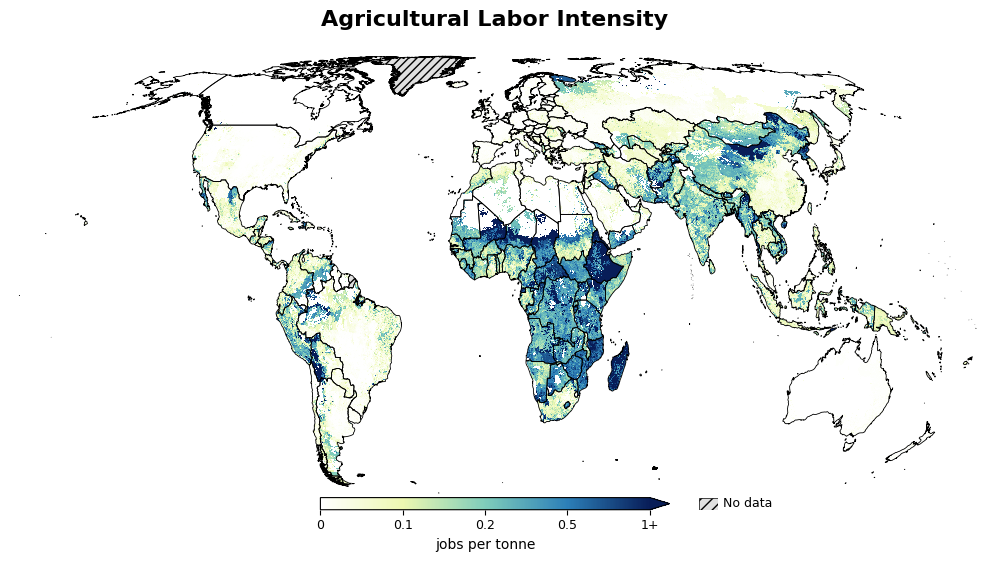

In [27]:
##### Produce global map of labor intensity

# Prepare raster
value_plot = labor_intensity.squeeze()
name = 'labor_intensity'

# set custom colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    "white_ylgnbu",
    ["#ffffff", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
)
custom_cmap.set_over("#081d58")  # color for the + triangle

# Set special equal-distant, manual scalling
bounds = [0, 0.1, 0.2, 0.5, 1]      
labels = ['0', '0.1', '0.2', '0.5', '1+']            

positions = np.linspace(0, 1, len(bounds))  # each bound gets an equal-width slice

def forward(x):
    return np.interp(x, bounds, positions)

def inverse(x):
    return np.interp(x, positions, bounds)

norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Countries with no data (light grey fill with hatching)
no_data_color = "#e0e0e0"
country_boundaries[country_boundaries["has_labor_data"] == 0].plot(
    ax=ax,
    facecolor=no_data_color,
    edgecolor="none",
    hatch="////",
    zorder=0
)

# Country borders
country_boundaries.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.6,
    zorder=2
)

# Raster
im = value_plot.plot(
    ax=ax,
    cmap=custom_cmap,
    norm=norm,
    add_colorbar=False,
    add_labels=False,
    zorder=1
)

ax.set_axis_off()
ax.set_title("Agricultural Labor Intensity", fontsize=16, weight='bold', pad=20)

# Generate legend 
cax = ax.inset_axes([0.32, 0.06, 0.36, 0.025], transform=ax.transAxes)

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    extend='max',       
    extendfrac=0.06,    
)
cbar.set_label("jobs per tonne", fontsize=10)
cbar.ax.tick_params(labelsize=9)

cbar.set_ticks(bounds)
cbar.set_ticklabels(labels)

# Add no data to legend
legend_ax = ax.inset_axes([0.71, 0.06, 0.02, 0.025], transform=ax.transAxes)
legend_ax.add_patch(Rectangle(
    (0, 0), 1, 1,
    facecolor=no_data_color,
    edgecolor="black",
    linewidth=0.5,
    hatch="///"
))
legend_ax.set_xlim(0, 1)
legend_ax.set_ylim(0, 1)
legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.axis("off")

ax.text(
    0.735, 0.072, "No data",
    transform=ax.transAxes,
    fontsize=9, va="center", ha="left"
)

plt.tight_layout()
plt.show()

fig.savefig(f"{fd}/{name}.png", dpi=300, bbox_inches='tight')

#### Map intensities (country/raster side-by-side)

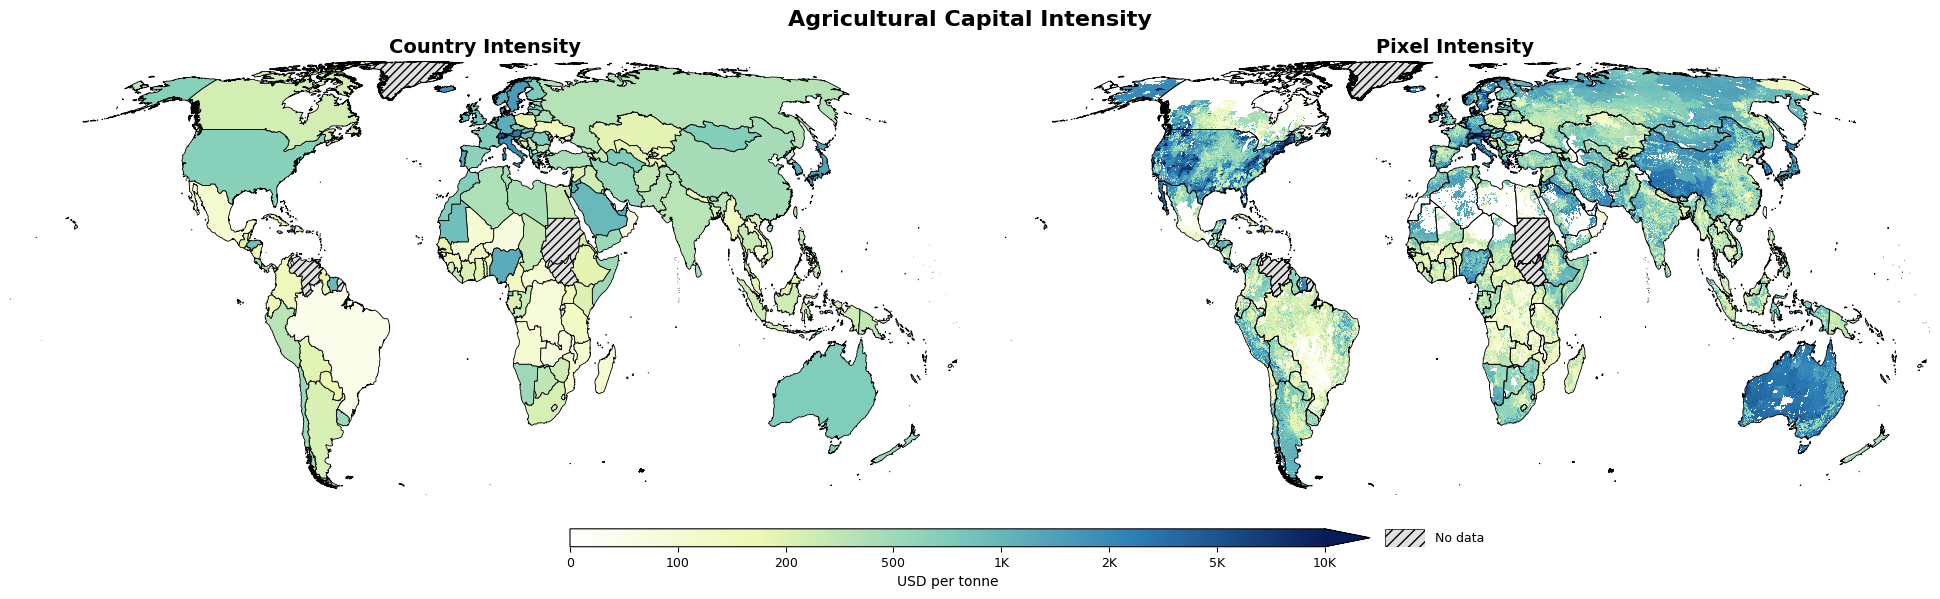

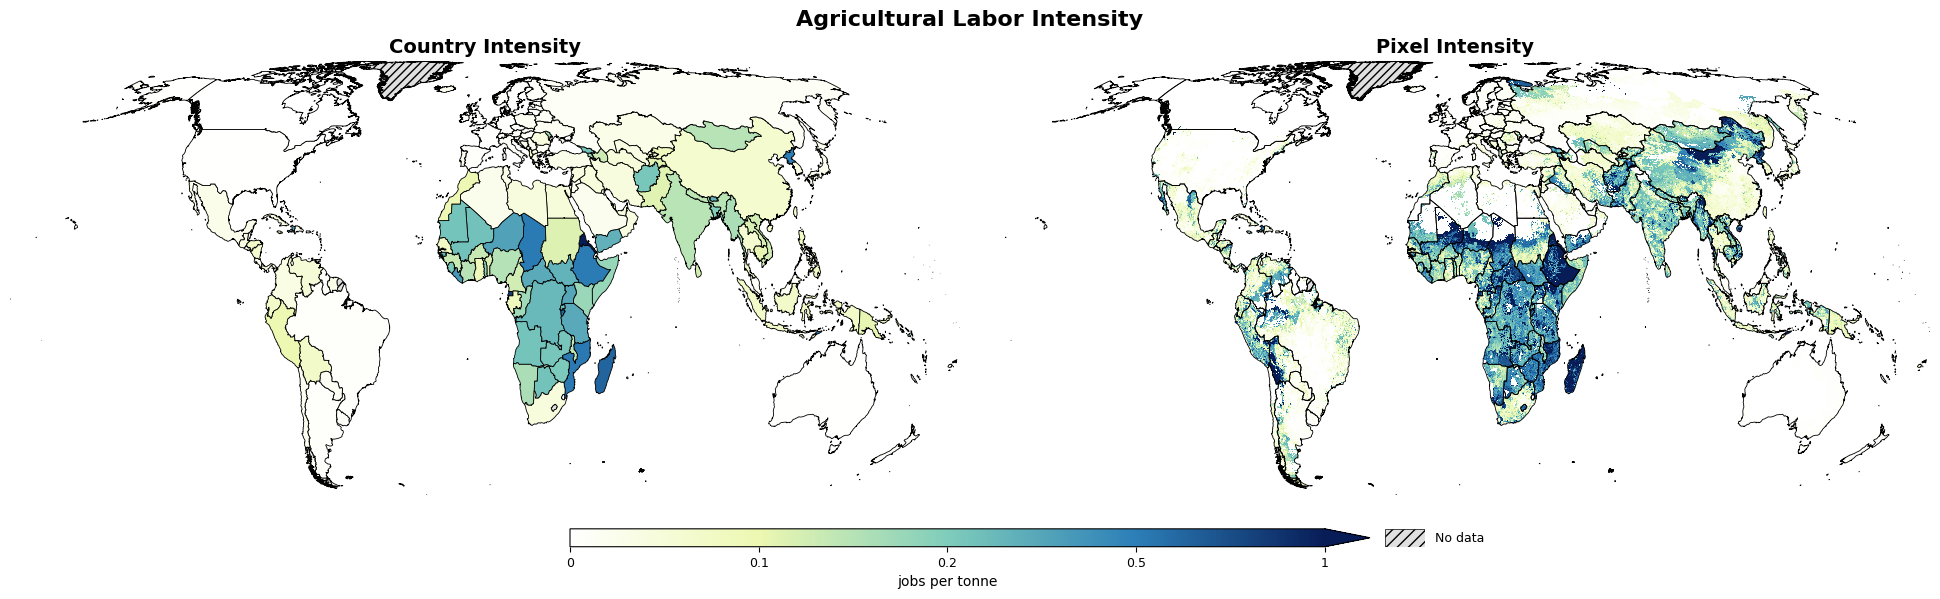

In [29]:
def plot_intensity_side_by_side(
    raster, country_gdf, value_col, coverage_col, bounds, labels,
    title, cbar_label, out_path, cmap=None, missing_color="#e0e0e0"
):

    value_plot = raster.squeeze()
    minx, miny, maxx, maxy = country_gdf.total_bounds

    # --- Custom white -> YlGnBu colormap (shared default, matches other intensity maps) ---
    if cmap is None:
        cmap = mcolors.LinearSegmentedColormap.from_list(
            "white_ylgnbu",
            ["#ffffff", "#edf8b1", "#7fcdbb", "#2c7fb8", "#081d58"]
        )
        cmap.set_over("#081d58")

    # --- Piecewise-linear scaling: equal spacing between bounds, regardless of real magnitude ---
    positions = np.linspace(0, 1, len(bounds))

    def forward(x):
        return np.interp(x, bounds, positions)

    def inverse(x):
        return np.interp(x, positions, bounds)

    norm = mcolors.FuncNorm((forward, inverse), vmin=bounds[0], vmax=bounds[-1])

    # --- Compute figure height from actual data aspect ratio to kill excess whitespace ---
    data_w = maxx - minx
    data_h = maxy - miny
    fig_width = 20  # narrower total width since we're down to 2 panels
    panel_width = fig_width / 2
    map_height = panel_width * (data_h / data_w)
    fig_height = map_height + 1.4  # buffer for title + bottom colorbar/legend row

    fig, axes = plt.subplots(1, 2, figsize=(fig_width, fig_height))

    # --- Panel 1: country-level choropleth ---
    ax0 = axes[0]

    country_has_data = country_gdf[country_gdf[coverage_col] == 1]
    country_no_data = country_gdf[country_gdf[coverage_col] == 0]

    country_no_data.plot(ax=ax0, facecolor=missing_color, edgecolor="black", linewidth=0.6, hatch="////", zorder=1)
    country_has_data.plot(
        ax=ax0, column=value_col, cmap=cmap, norm=norm,
        edgecolor="black", linewidth=0.6, zorder=2
    )

    ax0.set_xlim(minx, maxx)
    ax0.set_ylim(miny, maxy)
    ax0.set_aspect("equal")
    ax0.set_axis_off()
    ax0.set_title("Country Intensity", fontsize=14, weight="bold")

    # --- Panel 2: pixel intensity ---
    ax1 = axes[1]

    country_gdf[country_gdf[coverage_col] == 0].plot(
        ax=ax1, facecolor=missing_color, edgecolor="black", linewidth=0.6, hatch="////", zorder=1
    )

    im = value_plot.plot(
        ax=ax1, cmap=cmap, norm=norm,
        add_colorbar=False, add_labels=False, zorder=2
    )

    country_gdf.plot(ax=ax1, facecolor="none", edgecolor="black", linewidth=0.6, zorder=3)

    ax1.set_xlim(minx, maxx)
    ax1.set_ylim(miny, maxy)
    ax1.set_aspect("equal")
    ax1.set_axis_off()
    ax1.set_title("Pixel Intensity", fontsize=14, weight="bold")

    fig.suptitle(title, fontsize=16, weight="bold", y=0.98)

    # --- Tighten margins so panels fill the figure ---
    fig.subplots_adjust(left=0.02, right=0.98, top=0.90, bottom=0.16, wspace=0.02)

    # --- Shared horizontal colorbar along the bottom, with "+" triangle ---
    cbar_ax = fig.add_axes([0.30, 0.08, 0.4, 0.03])  # [left, bottom, width, height]
    cbar = fig.colorbar(
        im, cax=cbar_ax, orientation="horizontal",
        extend='max', extendfrac=0.06,
    )
    cbar.set_label(cbar_label, fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    cbar.set_ticks(bounds)
    cbar.set_ticklabels(labels)

    # --- Missing-data legend, positioned next to the colorbar ---
    fig.canvas.draw()
    cbar_pos = cbar.ax.get_position()

    swatch_size = 0.02
    gap = 0.03

    legend_ax = fig.add_axes([
        cbar_pos.x1 + gap,
        cbar_pos.y0,
        swatch_size,
        cbar_pos.height
    ])
    legend_ax.add_patch(mpatches.Rectangle(
        (0, 0), 1, 1,
        facecolor=missing_color,
        edgecolor="black",
        linewidth=0.5,
        hatch="///"
    ))
    legend_ax.set_xlim(0, 1)
    legend_ax.set_ylim(0, 1)
    legend_ax.set_xticks([])
    legend_ax.set_yticks([])
    legend_ax.axis("off")

    fig.text(
        cbar_pos.x1 + gap + swatch_size + 0.005,
        cbar_pos.y0 + cbar_pos.height / 2,
        "No data",
        fontsize=9, va="center", ha="left"
    )

    fig.savefig(out_path, dpi=300, bbox_inches="tight", pad_inches=0.1)
    plt.show()


# --- Capital intensity ---
plot_intensity_side_by_side(
    raster=capital_intensity,
    country_gdf=country_boundaries,
    value_col="capital_intensity_USD_per_tonne",
    coverage_col="has_capital_data",
    bounds=[0, 100, 200, 500, 1000, 2000, 5000, 10000],
    labels=['0', '100', '200', '500', '1K', '2K', '5K', '10K'],
    title="Agricultural Capital Intensity",
    cbar_label="USD per tonne",
    out_path=f"{fd}/capital_intensity_side_by_side.png",
)

# --- Labor intensity ---
plot_intensity_side_by_side(
    raster=labor_intensity,
    country_gdf=country_boundaries,
    value_col="labor_intensity_jobs_per_tonne",
    coverage_col="has_labor_data",
    bounds=[0, 0.1, 0.2, 0.5, 1],
    labels=['0', '0.1', '0.2', '0.5', '1'],
    title="Agricultural Labor Intensity",
    cbar_label="jobs per tonne",
    out_path=f"{fd}/labor_intensity_side_by_side.png",
)

#### Map sub-national intensities side-by-side